<a href="https://colab.research.google.com/github/swahar2/Python/blob/main/us_medical_insurance_costs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U.S. Medical Insurance Costs

In this project, We will find the Avreage insurance Cost.
Check the maximum and minimum insurance cost and will check all the parameters of max and min insurance cost

Check average insurance cost for males and average insurance cost for females
Check average insurance cost for Smokers and Non-smokers
Check average insurance cost for male and non-smoker, and male and smoker
Check average insurance cost for female and non-smoker, and female and smoker

Check Avreage insurance cost with number of children.
Check Avreage insurance cost for young, middle-age and senior citizens

#Importing the csv file

In [4]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


#Loading the CSV file

In [5]:
with open("insurance.csv") as insurance_csv:
  text = insurance_csv.read()
print(text)

age,sex,bmi,children,smoker,region,charges
19,female,27.9,0,yes,southwest,16884.924
18,male,33.77,1,no,southeast,1725.5523
28,male,33,3,no,southeast,4449.462
33,male,22.705,0,no,northwest,21984.47061
32,male,28.88,0,no,northwest,3866.8552
31,female,25.74,0,no,southeast,3756.6216
46,female,33.44,1,no,southeast,8240.5896
37,female,27.74,3,no,northwest,7281.5056
37,male,29.83,2,no,northeast,6406.4107
60,female,25.84,0,no,northwest,28923.13692
25,male,26.22,0,no,northeast,2721.3208
62,female,26.29,0,yes,southeast,27808.7251
23,male,34.4,0,no,southwest,1826.843
56,female,39.82,0,no,southeast,11090.7178
27,male,42.13,0,yes,southeast,39611.7577
19,male,24.6,1,no,southwest,1837.237
52,female,30.78,1,no,northeast,10797.3362
23,male,23.845,0,no,northeast,2395.17155
56,male,40.3,0,no,southwest,10602.385
30,male,35.3,0,yes,southwest,36837.467
60,female,36.005,0,no,northeast,13228.84695
30,female,32.4,1,no,southwest,4149.736
18,male,34.1,0,no,southeast,1137.011
34,female,31.92,1,yes,northeast,37701

#Loading the file as pandas dataframe

In [8]:
import pandas as pd

insurance = pd.read_csv("insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#Cleaning the Dataset

#Checking Null values

In [19]:
null_values = insurance.isnull().sum()
print(null_values)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


#Describe

In [20]:
outliers = insurance.describe()
print(outliers)

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


#Box Plot to check outliers

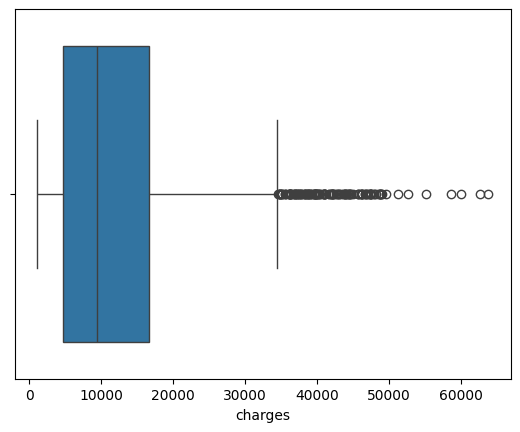

In [21]:
#Insurance Outliers
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=insurance["charges"])
plt.show()

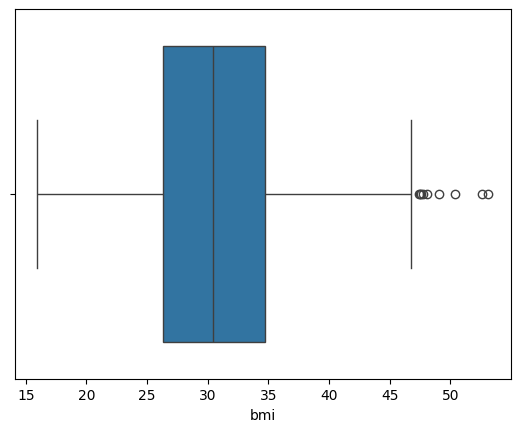

In [22]:
#BMI Outliers
sns.boxplot(x=insurance["bmi"])
plt.show()

#Fixing the Outliers

In [25]:
insurance['charges_outliers_fixed'] = insurance['charges'].apply(lambda x: insurance['charges'].median() if x > 50000 else x)
insurance['bmi_outliers_fixed'] = insurance['bmi'].apply(lambda x: insurance['bmi'].median() if x > 50 else x)
insurance

,age,sex,bmi,children,smoker,region,charges,charges_outliers_fixed,bmi_outliers_fixed
0,19,female,27.900,0,yes,southwest,16884.92400,16884.92400,27.900
1,18,male,33.770,1,no,southeast,1725.55230,1725.55230,33.770
2,28,male,33.000,3,no,southeast,4449.46200,4449.46200,33.000
3,33,male,22.705,0,no,northwest,21984.47061,21984.47061,22.705
4,32,male,28.880,0,no,northwest,3866.85520,3866.85520,28.880
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,10600.54830,30.970
1334,18,female,31.920,0,no,northeast,2205.98080,2205.98080,31.920
1335,18,female,36.850,0,no,southeast,1629.83350,1629.83350,36.850
1336,21,female,25.800,0,no,southwest,2007.94500,2007.94500,25.800


#Average Insurance Cost

In [9]:
average_insurance_cost = insurance["charges"].mean()
print("The average insurance cost is", average_insurance_cost)

The average insurance cost is 13270.422265141257


#Maximum and Minimum Insurance Cost and the parameters of both the max and min cost

In [10]:
#Maximum Insurance Cost
from numpy import maximum
maximum_insurance_cost = insurance["charges"].max()
print("The maximum insurance cost is", maximum_insurance_cost)

The maximum insurance cost is 63770.42801


In [12]:
#Minimum Insurance Cost
minimum_insurance_cost = insurance["charges"].min()
print("The minimum insurance cost is", minimum_insurance_cost)

The minimum insurance cost is 1121.8739


In [13]:
#Parameters of maximum Insurance Cost
insurance[insurance["charges"] == maximum_insurance_cost]

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801


In [15]:
#Parameters of Minimum Insurance Cost
insurance[insurance["charges"] == minimum_insurance_cost]

,age,sex,bmi,children,smoker,region,charges
940,18,male,23.21,0,no,southeast,1121.8739


#Average Insurance Cost for Males and Females

In [16]:
#Average insurance cost for males
average_insurance_cost_male = insurance[insurance["sex"] == "male"]["charges"].mean()
print("The average insurance cost for males is", average_insurance_cost_male)

The average insurance cost for males is 13956.751177721893


In [17]:
#Average insurance cost for females
average_insurance_cost_females = insurance[insurance["sex"] == 'female']['charges'].mean()
print("The average insurance cost for females is", average_insurance_cost_females)

The average insurance cost for females is 12569.578843835347


#Average Insurance Cost for Smokers and Non-Smokers

In [18]:
#Average Inusrance Cost for Smokers
average_insurance_cost_smoker = insurance[insurance['smoker'] == 'yes']['charges'].mean()
print("The average insurance cost for smokers is", average_insurance_cost_smoker)

The average insurance cost for smokers is 32050.23183153284


In [26]:
#Average Insurance Cost for Non-Smokes
average_insurance_cost_non_smoker = insurance[insurance['smoker'] == 'no']['charges'].mean()
print("The average insurance cost for non-smokers is", average_insurance_cost_non_smoker)

The average insurance cost for non-smokers is 8434.268297856204


#Check Average Cost for Male and Smoker, and Male and Non-smoker

In [27]:
#Average Insurance Cost for Male and Smoker
average_insurance_cost_male_smoker = insurance[(insurance['sex'] == 'male') & (insurance['smoker'] == 'yes')]['charges'].mean()
print("The average insurance cost for male and smokers is", average_insurance_cost_male_smoker)

The average insurance cost for male and smokers is 33042.00597528303


In [28]:
#Average Insurance Cost for Male and Non-Smoker
average_insurance_cost_male_non_smoker = insurance[(insurance['sex'] == 'male') & (insurance['smoker'] == 'no')]['charges'].mean()
print("The average insurance cost for male and non-smokers is", average_insurance_cost_male_non_smoker)

The average insurance cost for male and non-smokers is 8087.204731276595


#Check Average Cost for Female and Smoker, and Female and Non-smoker

In [29]:
#Average insurance cost for female and smoker
average_insurance_cost_female_smoker = insurance[(insurance['sex'] == 'female') & (insurance['smoker'] == 'yes')]['charges'].mean()
print("The average insurance cost for female and smokers is", average_insurance_cost_female_smoker)

The average insurance cost for female and smokers is 30678.996276260867


In [31]:
#Average Insurance Cost for female and non-smoker
average_insurance_cost_female_non_smoker = insurance[(insurance['sex'] == 'female') & (insurance['smoker'] == 'no')]['charges'].mean()
print("The average insurance cost for female and non-smokers is", average_insurance_cost_female_non_smoker)

The average insurance cost for female and non-smokers is 8762.297299541133


#Average Insurance grouping number of children

In [32]:
average_insurance_cost_with_children = insurance.groupby('children')['charges'].mean().reset_index()
average_insurance_cost_with_children

,children,charges
0,0,12365.975602
1,1,12731.171832
2,2,15073.563734
3,3,15355.318367
4,4,13850.656311
5,5,8786.035247


#Average Insurance Cost grouping Young, Middle age and Senior citizens

In [36]:
#Average Insurance Cost of Young Citizens

average_insurance_cost_young = insurance[insurance['age'] < 30]['charges'].mean()
print("The average insurance cost for young citizens is", average_insurance_cost_young)

The average insurance cost for young citizens is 9182.487125153477


In [35]:
#Average Insurance Cost of Middle Age Citizens

average_insurance_cost_middle_age = insurance[(insurance['age'] >= 30) & (insurance['age'] < 60)]['charges'].mean()
print("The average insurance cost for middle age citizens is", average_insurance_cost_middle_age)

The average insurance cost for middle age citizens is 14255.828209033458


In [37]:
#Average Insurance Cost of Senior Citizens

average_insurance_cost_senior = insurance[insurance['age'] >= 60]['charges'].mean()
print("The average insurance cost for senior citizens is", average_insurance_cost_senior)

The average insurance cost for senior citizens is 21248.021884912283


#Putting all the average Cost in a Table/Dataframe Format

In [49]:
df_average_cost = pd.DataFrame({
    'Average Insurance Cost': [average_insurance_cost, average_insurance_cost_male, average_insurance_cost_male_smoker, average_insurance_cost_male_non_smoker, average_insurance_cost_females, average_insurance_cost_female_smoker, average_insurance_cost_female_non_smoker, average_insurance_cost_smoker, average_insurance_cost_non_smoker, average_insurance_cost_young, average_insurance_cost_middle_age, average_insurance_cost_senior]}, index = ["Total Average Insurance Cost", 'average_insurance_cost_male', 'average_insurance_cost_male_smoker', 'average_insurance_cost_male_non_smoker', 'average_insurance_cost_female', 'average_insurance_cost_female_smoker', 'average_insurance_cost_female_non_smoker', 'average_insurance_cost_smoker', 'average_insurance_cost_non_smoker', 'average_insurance_cost_young', 'average_insurance_cost_middle_age' , 'average_insurance_cost_senior'])

In [50]:
df_average_cost

,Average Insurance Cost
Total Average Insurance Cost,13270.422265
average_insurance_cost_male,13956.751178
average_insurance_cost_male_smoker,33042.005975
average_insurance_cost_male_non_smoker,8087.204731
average_insurance_cost_female,12569.578844
average_insurance_cost_female_smoker,30678.996276
average_insurance_cost_female_non_smoker,8762.297300
average_insurance_cost_smoker,32050.231832
average_insurance_cost_non_smoker,8434.268298
average_insurance_cost_young,9182.487125


In [73]:
#maximum average insurance cost
maximum_average_insurance_cost = df_average_cost.max()
maximum_average_insurance_cost

df_average_cost[df_average_cost == maximum_average_insurance_cost]

,Average Insurance Cost
Total Average Insurance Cost,NaN
average_insurance_cost_male,NaN
average_insurance_cost_male_smoker,33042.005975
average_insurance_cost_male_non_smoker,NaN
average_insurance_cost_female,NaN
average_insurance_cost_female_smoker,NaN
average_insurance_cost_female_non_smoker,NaN
average_insurance_cost_smoker,NaN
average_insurance_cost_non_smoker,NaN
average_insurance_cost_young,NaN


In [75]:
#Average minimum insurance cost

minimum_average_insurance_cost = df_average_cost.min()
print (minimum_average_insurance_cost)

df_average_cost[df_average_cost == minimum_average_insurance_cost]

Average Insurance Cost    8087.204731
dtype: float64


,Average Insurance Cost
Total Average Insurance Cost,NaN
average_insurance_cost_male,NaN
average_insurance_cost_male_smoker,NaN
average_insurance_cost_male_non_smoker,8087.204731
average_insurance_cost_female,NaN
average_insurance_cost_female_smoker,NaN
average_insurance_cost_female_non_smoker,NaN
average_insurance_cost_smoker,NaN
average_insurance_cost_non_smoker,NaN
average_insurance_cost_young,NaN


In [76]:
df_average_cost.describe()

,Average Insurance Cost
count,12.000000
mean,17128.174493
std,9633.898837
min,8087.204731
25%,9077.439669
50%,13613.586721
75%,23605.765483
max,33042.005975
